# TrashCAN 1.0 Exploration (GENERALIZATION TESTING)
**Assigned to:** ___
**No GPU needed.**

Used AFTER training to test generalization on unseen data. Not for training.

In [10]:
import os
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / "requirements.txt").exists() and (p / "src").exists():
            return p
    return cur

def _is_colab() -> bool:
    return bool(os.environ.get("COLAB_RELEASE_TAG") or Path("/content").exists())

def _google_drive_roots() -> list[Path]:
    roots: list[Path] = []
    home = Path.home()

    # Google Drive for desktop (macOS)
    for pat in ["Library/CloudStorage/GoogleDrive-*/My Drive", "Library/CloudStorage/GoogleDrive*/My Drive"]:
        for p in home.glob(pat):
            if p.exists():
                roots.append(p)

    # Fallback user folders (sometimes people rename/symlink)
    for name in ["Google Drive", "GoogleDrive"]:
        p = home / name
        if p.exists():
            roots.append(p)

    # Colab Drive root (after mount)
    colab_root = Path("/content/drive/MyDrive")
    if colab_root.exists():
        roots.append(colab_root)

    # Mounted volumes (external disks, Google Drive mounts, etc.)
    volumes = Path("/Volumes")
    if volumes.exists():
        for vol in volumes.iterdir():
            if vol.is_dir():
                roots.append(vol)

    # De-dup while preserving order
    deduped: list[Path] = []
    seen = set()
    for r in roots:
        try:
            rp = str(r.resolve())
        except Exception:
            rp = str(r)
        if rp not in seen:
            seen.add(rp)
            deduped.append(r)
    return deduped

def _underwater_dataset_bases(drive_root: Path) -> list[Path]:
    bases: list[Path] = []
    direct = drive_root / "underwater_datasets"
    if direct.exists():
        bases.append(direct)

    # Google Drive shared drives layout
    shared = drive_root / "Shared drives"
    if shared.exists():
        for team_drive in shared.iterdir():
            if team_drive.is_dir():
                b = team_drive / "underwater_datasets"
                if b.exists():
                    bases.append(b)
    return bases

# NOTE: This notebook is meant to run locally (VS Code/Jupyter) as well as on Colab.
# Best option: set TRASHCAN_DATASET to the dataset root folder.
repo_root = _find_repo_root(Path.cwd())

# If actually running in Colab, try to mount Drive (safe-guarded to avoid local failures)
if _is_colab():
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive')
    except Exception:
        pass

env_path = os.environ.get("TRASHCAN_DATASET") or os.environ.get("DATASET")
candidates: list[Path] = []
if env_path:
    candidates.append(Path(env_path))

# Common repo-local locations (edit if your dataset lives elsewhere)
candidates += [
    repo_root / "data" / "TrashCAN 1.0",
    repo_root / "data" / "TrashCAN",
    repo_root / "data" / "trashcan",
    repo_root / "datasets" / "TrashCAN 1.0",
    repo_root / "datasets" / "TrashCAN",
    repo_root / "datasets" / "trashcan",
]

# Drive / external-drive locations
drive_roots = _google_drive_roots()
for drive_root in drive_roots:
    # direct candidates
    for base in _underwater_dataset_bases(drive_root) or [drive_root / "underwater_datasets"]:
        candidates.append(base / "TrashCAN 1.0")
        candidates.append(base / "TrashCAN")
        candidates.append(base / "trashcan")
        if base.exists():
            for child in base.iterdir():
                if child.is_dir() and "trashcan" in child.name.lower():
                    candidates.append(child)

# Best-effort search under repo_root/data or repo_root/datasets
for base in [repo_root / "data", repo_root / "datasets"]:
    if base.exists():
        for child in base.iterdir():
            if child.is_dir() and "trashcan" in child.name.lower():
                candidates.append(child)

DATASET_PATH = next((p for p in candidates if p.exists()), None)
if DATASET_PATH is None:
    print("⚠️ TrashCAN dataset not found.")
    print("Detected Drive roots (for debugging):")
    for r in drive_roots[:12]:
        print(f"  - {r}")
    if len(drive_roots) > 12:
        print(f"  ... ({len(drive_roots) - 12} more)")
    print("\nFix: set TRASHCAN_DATASET explicitly to the dataset folder, e.g.:")
    print("  export TRASHCAN_DATASET='/absolute/path/to/TrashCAN 1.0'")
else:
    print(f"✓ Using dataset: {DATASET_PATH}")

Mounted at /content/drive
✓ Using dataset: /content/drive/MyDrive/underwater_datasets/TrashCAN 1.0


In [17]:
from pathlib import Path
from collections import Counter
import os

if DATASET_PATH is None:
    print("Skipping directory scan (dataset not configured).")
else:
    root = Path(DATASET_PATH)
    exts = Counter(p.suffix.lower() for p in root.rglob("*") if p.is_file())
    img_count = sum(exts[e] for e in [".jpg", ".jpeg", ".png"] if e in exts)
    print("=== DATASET FILE SNAPSHOT ===")
    print(f"Root: {root}")
    print(f"Total files: {sum(exts.values())}")
    print(f"Image files: {img_count}")
    print("Top extensions:")
    for e, c in exts.most_common(12):
        print(f"  {e or '[no_ext]'}: {c}")

    # Keep a reusable metric for later cells
    NUM_IMAGES = img_count

=== DATASET FILE SNAPSHOT ===
Root: /content/drive/MyDrive/underwater_datasets/TrashCAN 1.0
Total files: 28937
Image files: 21715
Top extensions:
  .jpg: 21715
  .json: 7217
  .txt: 4
  .py: 1


In [18]:
# === DETECT ANNOTATION FORMAT (robust) ===
from pathlib import Path
import json
import xml.etree.ElementTree as ET

def _looks_like_yolo_line(line: str) -> bool:
    p = line.strip().split()
    if len(p) != 5:
        return False
    try:
        int(float(p[0]))
        vals = [float(x) for x in p[1:]]
        return all(v >= 0 for v in vals)
    except Exception:
        return False

if DATASET_PATH is None:
    print("Skipping annotation-format detection (dataset not configured).")
else:
    root = Path(DATASET_PATH)
    txts = sorted(root.rglob("*.txt"))
    xmls = sorted(root.rglob("*.xml"))
    jsons = sorted(root.rglob("*.json"))
    csvs = sorted(root.rglob("*.csv"))
    print(f".txt: {len(txts)} | .xml: {len(xmls)} | .json: {len(jsons)} | .csv: {len(csvs)}")

    yolo_like = 0
    yolo_checked = 0
    for t in txts[:1000]:
        try:
            lines = [ln.strip() for ln in t.read_text(errors="ignore").splitlines() if ln.strip()]
            if not lines:
                continue
            yolo_checked += 1
            ok = sum(_looks_like_yolo_line(ln) for ln in lines[:20])
            if ok >= max(1, int(0.6 * min(20, len(lines)))):
                yolo_like += 1
        except Exception:
            pass

    coco_like = 0
    for j in jsons[:200]:
        try:
            d = json.loads(j.read_text(errors="ignore"))
            if isinstance(d, dict) and {"images", "annotations", "categories"}.issubset(set(d.keys())):
                coco_like += 1
        except Exception:
            pass

    voc_like = 0
    for x in xmls[:1000]:
        try:
            tree = ET.parse(x)
            if tree.getroot().find("object") is not None:
                voc_like += 1
        except Exception:
            pass

    scores = {"YOLO": yolo_like, "COCO": coco_like, "VOC": voc_like}
    ANNOTATION_FORMAT = max(scores, key=scores.get) if any(scores.values()) else "Unknown"
    print(f"Likely annotation format: {ANNOTATION_FORMAT} | scores: {scores}")

    # Save category map if COCO
    COCO_CATEGORIES = {}
    if ANNOTATION_FORMAT == "COCO":
        for j in jsons[:20]:
            try:
                d = json.loads(j.read_text(errors="ignore"))
                cats = d.get("categories", []) if isinstance(d, dict) else []
                if cats:
                    COCO_CATEGORIES = {c.get("id"): c.get("name", str(c.get("id"))) for c in cats if isinstance(c, dict)}
                    break
            except Exception:
                pass

.txt: 4 | .xml: 0 | .json: 7217 | .csv: 0
Likely annotation format: COCO | scores: {'YOLO': 0, 'COCO': 4, 'VOC': 0}


In [19]:
# === CLASS DISTRIBUTION (format-aware) ===
from collections import Counter
from pathlib import Path
import json
import xml.etree.ElementTree as ET

if DATASET_PATH is None:
    print("Skipping class distribution (dataset not configured).")
else:
    root = Path(DATASET_PATH)
    fmt = globals().get("ANNOTATION_FORMAT", "Unknown")
    counts = Counter()
    total_boxes = 0
    bad_boxes = 0

    if fmt == "YOLO":
        for t in root.rglob("*.txt"):
            try:
                for l in t.read_text(errors="ignore").splitlines():
                    p = l.strip().split()
                    if len(p) != 5:
                        continue
                    c, x, y, w, h = p
                    c = int(float(c))
                    x, y, w, h = float(x), float(y), float(w), float(h)
                    counts[c] += 1
                    total_boxes += 1
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                        bad_boxes += 1
            except Exception:
                pass
    elif fmt == "COCO":
        for j in root.rglob("*.json"):
            try:
                d = json.loads(j.read_text(errors="ignore"))
                if not (isinstance(d, dict) and "annotations" in d):
                    continue
                for a in d["annotations"]:
                    c = a.get("category_id", -1)
                    counts[c] += 1
                    total_boxes += 1
                    b = a.get("bbox")
                    if isinstance(b, list) and len(b) >= 4 and (b[2] <= 0 or b[3] <= 0):
                        bad_boxes += 1
            except Exception:
                pass
    elif fmt == "VOC":
        for x in root.rglob("*.xml"):
            try:
                tree = ET.parse(x)
                for obj in tree.getroot().findall("object"):
                    name = obj.findtext("name", default="unknown")
                    counts[name] += 1
                    total_boxes += 1
                    bb = obj.find("bndbox")
                    if bb is None:
                        bad_boxes += 1
                        continue
                    xmin = float(bb.findtext("xmin", default="0"))
                    ymin = float(bb.findtext("ymin", default="0"))
                    xmax = float(bb.findtext("xmax", default="0"))
                    ymax = float(bb.findtext("ymax", default="0"))
                    if xmax <= xmin or ymax <= ymin:
                        bad_boxes += 1
            except Exception:
                pass
    else:
        print("Unknown annotation format. Run Cell 4 first.")

    if counts:
        print(f"Classes found: {len(counts)} | Total boxes: {total_boxes} | Bad boxes: {bad_boxes}")
        coco_names = globals().get("COCO_CATEGORIES", {})
        for k, v in counts.most_common(15):
            label = coco_names.get(k, k) if isinstance(coco_names, dict) else k
            print(f"  {label}: {v}")

    CLASS_COUNTS = counts
    TOTAL_BOXES = total_boxes
    BAD_BOXES = bad_boxes

Classes found: 22 | Total boxes: 24464 | Bad boxes: 0
  rov: 6634
  trash_unknown_instance: 2756
  trash_can: 2323
  trash_clothing: 2121
  trash_bag: 2034
  animal_fish: 1528
  plant: 1014
  trash_container: 850
  animal_starfish: 796
  animal_eel: 686
  animal_crab: 618
  animal_shells: 498
  animal_etc: 470
  trash_pipe: 470
  trash_branch: 336


Saved: /content/results/trashcan_samples.png


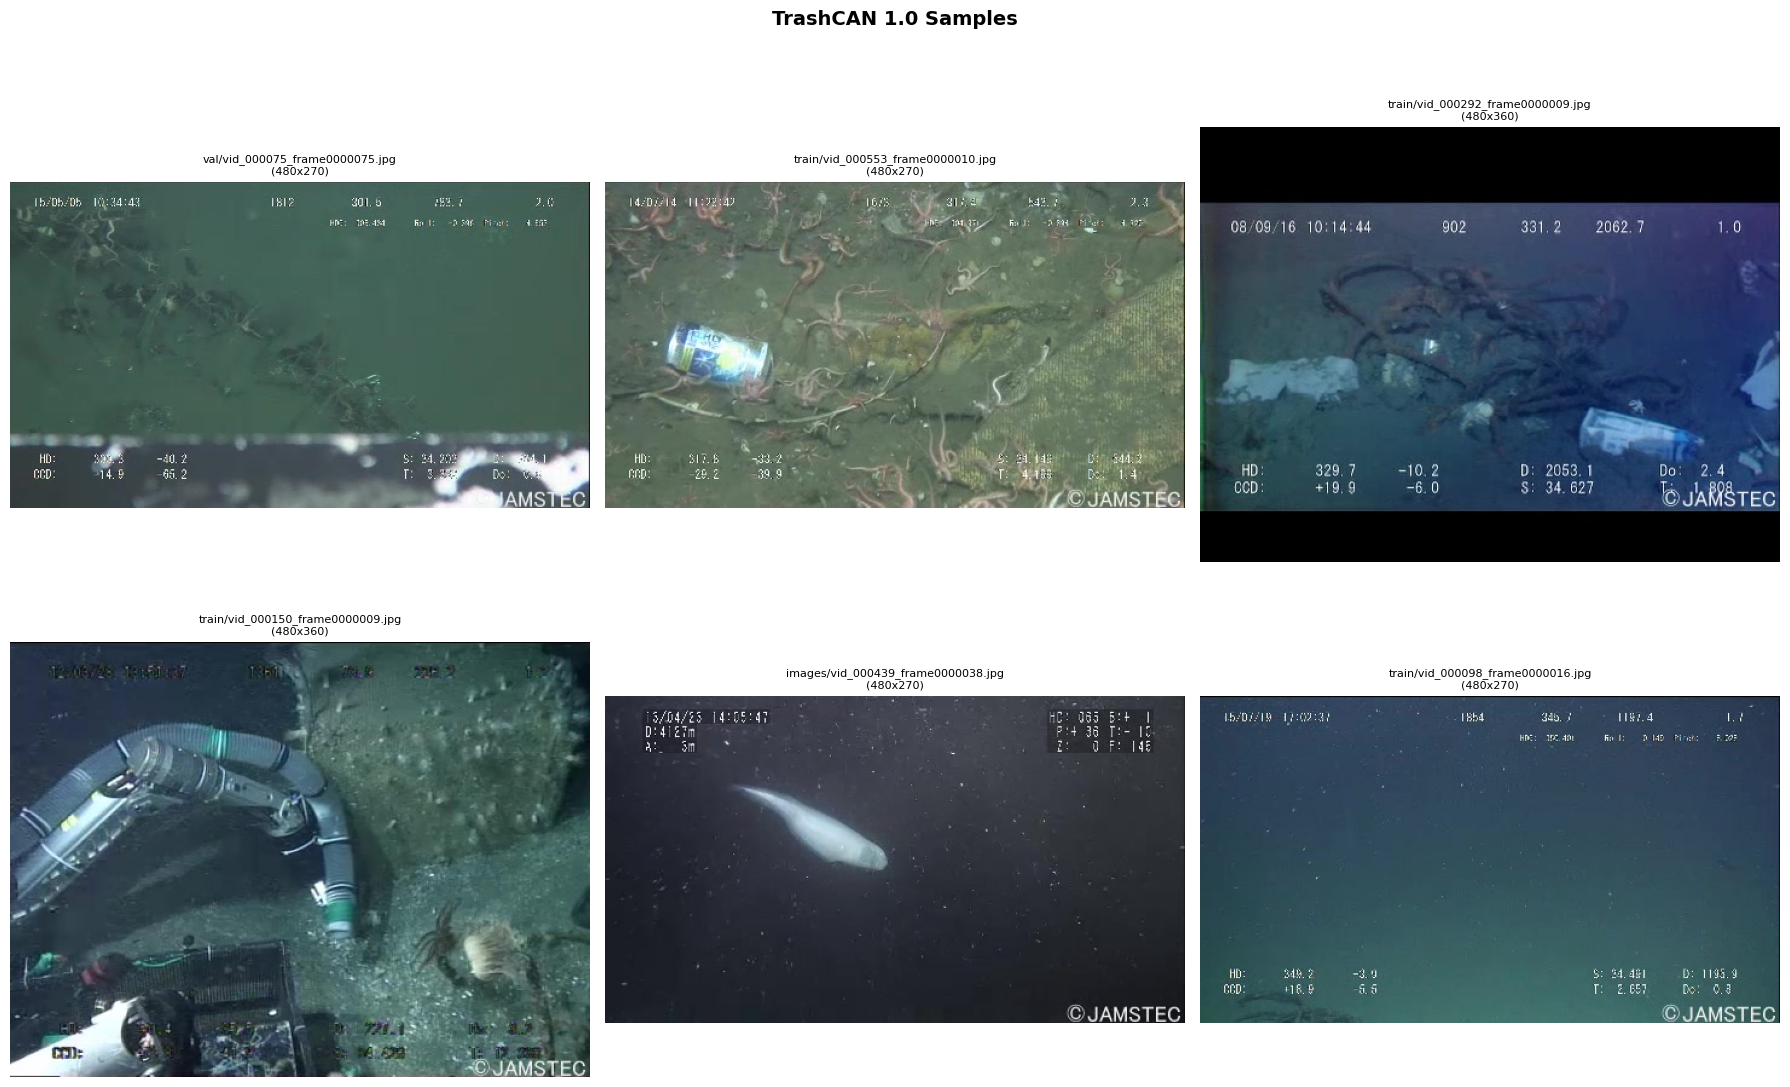

In [14]:
# === SAMPLE IMAGES ===
from pathlib import Path

if DATASET_PATH is None:
    print("Skipping sample images (dataset not configured).")
else:
    try:
        import cv2
        import numpy as np
        import matplotlib.pyplot as plt
    except Exception:
        print("Skipping image visualization (missing packages).")
        print("To enable it, install deps and re-run:")
        print("  pip install -r requirements.txt")
    else:
        root = Path(DATASET_PATH)
        imgs = sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.png"))
        if not imgs:
            print("No images!")
        else:
            np.random.seed(42)
            picks = [imgs[i] for i in np.random.choice(len(imgs), min(6, len(imgs)), replace=False)]
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            for i, p in enumerate(picks):
                ax = axes[i // 3][i % 3]
                img = cv2.imread(str(p))
                if img is not None:
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    ax.set_title(f"{p.parent.name}/{p.name}\n({img.shape[1]}x{img.shape[0]})", fontsize=8)
                ax.axis("off")
            plt.suptitle("TrashCAN 1.0 Samples", fontsize=14, fontweight="bold")
            plt.tight_layout()

            out_path = (repo_root / "results" / "trashcan_samples.png").resolve()
            out_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
            print(f"Saved: {out_path}")
            plt.show()

In [20]:
from pathlib import Path

fmt = globals().get("ANNOTATION_FORMAT", "Unknown")
nimg = globals().get("NUM_IMAGES", None)
if nimg is None and globals().get("DATASET_PATH") is not None:
    root = Path(DATASET_PATH)
    nimg = len(list(root.rglob("*.jpg"))) + len(list(root.rglob("*.jpeg"))) + len(list(root.rglob("*.png")))

counts = globals().get("CLASS_COUNTS", {})
num_classes = len(counts) if counts else "___"
total_boxes = globals().get("TOTAL_BOXES", "___")
bad_boxes = globals().get("BAD_BOXES", "___")

print("=" * 64)
print("TRASHCAN 1.0 SUMMARY")
print("=" * 64)
print(f"1. Total images: {nimg if nimg is not None else '___'}")
print(f"2. Annotation format: {fmt}")
print(f"3. Classes: {num_classes} (boxes: {total_boxes}, bad_boxes: {bad_boxes})")
print("4. Overlaps with Trash-ICRA19? NOT VERIFIED")
print("5. Can compute mAP? YES (once GT format+class map is finalized)")
print("6. Image sizes: mixed (see sample cell titles)")
print("=" * 64)

TRASHCAN 1.0 SUMMARY
1. Total images: 21715
2. Annotation format: COCO
3. Classes: 22 (boxes: 24464, bad_boxes: 0)
4. Overlaps with Trash-ICRA19? NOT VERIFIED
5. Can compute mAP? YES (once GT format+class map is finalized)
6. Image sizes: mixed (see sample cell titles)


In [16]:
# === NOTEBOOK AUDIT (compact) ===
from pathlib import Path
from collections import Counter
import json
import xml.etree.ElementTree as ET

if DATASET_PATH is None:
    print("Audit skipped: DATASET_PATH is not set.")
else:
    root = Path(DATASET_PATH)
    img_files = sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.jpeg")) + sorted(root.rglob("*.png"))
    txt_files = sorted(root.rglob("*.txt"))
    xml_files = sorted(root.rglob("*.xml"))
    json_files = sorted(root.rglob("*.json"))

    def looks_like_yolo_line(line: str) -> bool:
        p = line.strip().split()
        if len(p) != 5:
            return False
        try:
            int(float(p[0]))
            vals = [float(x) for x in p[1:]]
            return all(v >= 0 for v in vals)
        except Exception:
            return False

    # detect likely annotation format
    yolo_like = 0
    yolo_checked = 0
    for t in txt_files[:2000]:
        try:
            lines = [ln.strip() for ln in t.read_text(errors="ignore").splitlines() if ln.strip()]
            if not lines:
                continue
            yolo_checked += 1
            ok = sum(looks_like_yolo_line(ln) for ln in lines[:20])
            if ok >= max(1, int(0.6 * min(20, len(lines)))):
                yolo_like += 1
        except Exception:
            pass

    coco_like = 0
    for j in json_files[:200]:
        try:
            d = json.loads(j.read_text(errors="ignore"))
            if isinstance(d, dict) and {"images", "annotations", "categories"}.issubset(set(d.keys())):
                coco_like += 1
        except Exception:
            pass

    voc_like = 0
    for x in xml_files[:2000]:
        try:
            tree = ET.parse(x)
            if tree.getroot().find("object") is not None:
                voc_like += 1
        except Exception:
            pass

    fmt_scores = {"YOLO": yolo_like, "COCO": coco_like, "VOC": voc_like}
    likely_fmt = max(fmt_scores, key=fmt_scores.get) if any(fmt_scores.values()) else "Unknown"

    # class distribution parsing using the likely format
    class_counts = Counter()
    bad_boxes = 0
    total_boxes = 0

    if likely_fmt == "YOLO":
        for t in txt_files:
            try:
                for ln in t.read_text(errors="ignore").splitlines():
                    p = ln.strip().split()
                    if len(p) != 5:
                        continue
                    c, x, y, w, h = p
                    c = int(float(c))
                    x, y, w, h = float(x), float(y), float(w), float(h)
                    total_boxes += 1
                    class_counts[c] += 1
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                        bad_boxes += 1
            except Exception:
                pass
    elif likely_fmt == "COCO":
        for j in json_files:
            try:
                d = json.loads(j.read_text(errors="ignore"))
                if not (isinstance(d, dict) and "annotations" in d):
                    continue
                for a in d["annotations"]:
                    c = a.get("category_id", -1)
                    class_counts[c] += 1
                    total_boxes += 1
                    b = a.get("bbox")
                    if isinstance(b, list) and len(b) >= 4:
                        if b[2] <= 0 or b[3] <= 0:
                            bad_boxes += 1
            except Exception:
                pass
    elif likely_fmt == "VOC":
        for x in xml_files:
            try:
                tree = ET.parse(x)
                for obj in tree.getroot().findall("object"):
                    name = obj.findtext("name", default="unknown")
                    class_counts[name] += 1
                    total_boxes += 1
                    bb = obj.find("bndbox")
                    if bb is None:
                        bad_boxes += 1
                        continue
                    xmin = float(bb.findtext("xmin", default="0"))
                    ymin = float(bb.findtext("ymin", default="0"))
                    xmax = float(bb.findtext("xmax", default="0"))
                    ymax = float(bb.findtext("ymax", default="0"))
                    if xmax <= xmin or ymax <= ymin:
                        bad_boxes += 1
            except Exception:
                pass

    print("=== AUDIT SNAPSHOT ===")
    print(f"Dataset root: {root}")
    print(f"Images: {len(img_files)}")
    print(f"Files -> txt:{len(txt_files)} xml:{len(xml_files)} json:{len(json_files)}")
    print(f"Likely annotation format: {likely_fmt} | scores: {fmt_scores}")
    print(f"Total boxes parsed: {total_boxes}")
    print(f"Classes parsed: {len(class_counts)}")
    topk = class_counts.most_common(10)
    print(f"Top classes: {topk}")
    print(f"Bad boxes: {bad_boxes} ({(100*bad_boxes/total_boxes):.2f}% if total_boxes else 0)")

    # NOTE: overlap with Trash-ICRA19 cannot be established here without loading that dataset too.
    print("Overlap with Trash-ICRA19: NOT VERIFIED (need Trash-ICRA19 path + duplicate check).")

=== AUDIT SNAPSHOT ===
Dataset root: /content/drive/MyDrive/underwater_datasets/TrashCAN 1.0
Images: 21715
Files -> txt:4 xml:0 json:7217
Likely annotation format: COCO | scores: {'YOLO': 0, 'COCO': 4, 'VOC': 0}
Total boxes parsed: 24464
Classes parsed: 22
Top classes: [(1, 6634), (17, 2756), (14, 2323), (9, 2121), (12, 2034), (3, 1528), (2, 1014), (16, 850), (4, 796), (7, 686)]
Bad boxes: 0 (0.00% if total_boxes else 0)
Overlap with Trash-ICRA19: NOT VERIFIED (need Trash-ICRA19 path + duplicate check).


In [22]:
# === EXPORT IMPORTANT RESULTS TO DRIVE ===
from pathlib import Path
from datetime import datetime, timezone
import json
import shutil

if DATASET_PATH is None:
    print("Export skipped: DATASET_PATH is not set.")
else:
    dataset_root = Path(DATASET_PATH)
    drive_root = dataset_root.parents[1] if len(dataset_root.parents) >= 2 else dataset_root
    export_dir = drive_root / "analysis_results" / "trashcan_explore"
    export_dir.mkdir(parents=True, exist_ok=True)

    counts = globals().get("CLASS_COUNTS", {})
    counts_dict = {str(k): int(v) for k, v in dict(counts).items()} if counts else {}

    report = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "dataset_path": str(dataset_root),
        "annotation_format": globals().get("ANNOTATION_FORMAT", "Unknown"),
        "num_images": int(globals().get("NUM_IMAGES", 0) or 0),
        "total_boxes": int(globals().get("TOTAL_BOXES", 0) or 0),
        "bad_boxes": int(globals().get("BAD_BOXES", 0) or 0),
        "num_classes": len(counts_dict),
        "class_counts": counts_dict,
        "notes": [
            "Overlap with Trash-ICRA19 is NOT verified in this notebook.",
            "Use hash-based duplicate check across datasets before claiming zero leakage."
        ]
    }

    json_path = export_dir / "trashcan_explore_report.json"
    txt_path = export_dir / "trashcan_explore_report.txt"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("TRASHCAN EXPLORATION REPORT\n")
        f.write("=" * 32 + "\n")
        f.write(f"dataset_path: {report['dataset_path']}\n")
        f.write(f"annotation_format: {report['annotation_format']}\n")
        f.write(f"num_images: {report['num_images']}\n")
        f.write(f"total_boxes: {report['total_boxes']}\n")
        f.write(f"bad_boxes: {report['bad_boxes']}\n")
        f.write(f"num_classes: {report['num_classes']}\n")
        f.write("top_classes:\n")
        for k, v in sorted(counts_dict.items(), key=lambda kv: kv[1], reverse=True)[:20]:
            f.write(f"  {k}: {v}\n")
        f.write("notes:\n")
        for n in report["notes"]:
            f.write(f"  - {n}\n")

    # Copy sample image artifact if produced
    sample_img = (repo_root / "results" / "trashcan_samples.png").resolve()
    if sample_img.exists():
        shutil.copy2(sample_img, export_dir / "trashcan_samples.png")

    print(f"Saved JSON: {json_path}")
    print(f"Saved TXT:  {txt_path}")
    if (export_dir / "trashcan_samples.png").exists():
        print(f"Saved IMG:  {export_dir / 'trashcan_samples.png'}")

Saved JSON: /content/drive/MyDrive/analysis_results/trashcan_explore/trashcan_explore_report.json
Saved TXT:  /content/drive/MyDrive/analysis_results/trashcan_explore/trashcan_explore_report.txt
Saved IMG:  /content/drive/MyDrive/analysis_results/trashcan_explore/trashcan_samples.png
